# Trend Research: key rate + moving market trend blocks

**Goal.** Compare several trend constructions on the clean quarterly market series and answer a practical question: which combination predicts the market level best on average when we evaluate on many blocked test windows.

**Constraints.**
- Use only the key-rate block from macro data, not the full macro basket.
- Train on multiple time periods.
- Hold out a contiguous test block, but allow later history to remain available for the training rows outside the test block.
- Average the results across many test windows.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'cashflow' / 'market' / 'trend' / 'trend_research_utils.py').exists():
        ROOT = candidate
        break

if ROOT is None:
    raise RuntimeError('Could not locate repository root from current working directory')

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cashflow.market.trend.trend_research_utils import (
    DEFAULT_KEY_RATE_COLUMNS,
    DEFAULT_TREND_WINDOWS,
    ModelSpec,
    build_key_rate_feature_frame,
    build_model_pipeline,
    build_trend_feature_frame,
    extract_coefficients,
    generate_test_positions,
    load_trend_panel,
    regression_metrics,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')

panel = load_trend_panel(ROOT)
panel['quarter_label'] = panel['quarter_norm'].astype(str)
target_col = 'market_log_level_q'
y = panel[target_col].to_numpy(dtype=float)
key_rate_frame = build_key_rate_feature_frame(panel).reset_index(drop=True)
trend_frame_template = build_trend_feature_frame(y, test_start=1, test_end=2, windows=DEFAULT_TREND_WINDOWS)
trend_columns = trend_frame_template.columns.tolist()
key_rate_columns = key_rate_frame.columns.tolist()

DATA_DIR = ROOT / 'cashflow' / 'market' / 'trend' / 'data'
FIGURES_DIR = DATA_DIR / 'figures'
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Panel rows: {len(panel)}')
print(f'Quarter range: {panel.quarter_norm.iloc[0]} -> {panel.quarter_norm.iloc[-1]}')
print(f'Trend windows: {DEFAULT_TREND_WINDOWS}')
print(f'Key-rate columns: {key_rate_columns}')


Panel rows: 45
Quarter range: 2015Q1 -> 2026Q1
Trend windows: (3, 6, 10)
Key-rate columns: ['key_rate_avg_q', 'key_rate_eoq', 'key_rate_min_q', 'key_rate_max_q', 'key_rate_log_return_q', 'key_rate_qoq_change', 'key_rate_spread_q', 'key_rate_ma_4', 'key_rate_ema_4', 'key_rate_ma_8', 'key_rate_ema_8']


## 1. Data Check

The clean market series is the target. Key-rate features come from `macro_quarterly_Moscow.csv` and are the only macro inputs we keep.
The target is quarterly `log(market)` in `market_log_level_q`.

,quarter_norm,market_log_level_q,actual_log_price_median,key_rate_avg_q,key_rate_eoq,key_rate_qoq_change
0,2015Q1,12.733139,12.510335,15.533333,14.0,-3.0
1,2015Q2,12.225860,12.194887,12.895604,11.5,-2.5
2,2015Q3,12.353107,12.804537,11.179348,11.0,-0.5
3,2015Q4,11.979400,12.018603,11.000000,11.0,0.0
4,2016Q1,11.934835,11.982435,11.000000,11.0,0.0
5,2016Q2,11.931919,11.957425,10.906593,10.5,-0.5
6,2016Q3,11.968232,12.045880,10.434783,10.0,-0.5
7,2016Q4,11.963010,12.007301,10.000000,10.0,0.0


,quarter_norm,market_log_level_q,actual_log_price_median,key_rate_avg_q,key_rate_eoq,key_rate_qoq_change
37,2024Q2,12.841057,12.902886,16.000000,16.0,0.0
38,2024Q3,12.817764,12.916379,17.554348,19.0,3.0
39,2024Q4,12.822821,12.898047,20.413043,21.0,2.0
40,2025Q1,12.842702,12.901966,21.000000,21.0,0.0
41,2025Q2,12.886382,12.914108,20.758242,20.0,-1.0
42,2025Q3,12.944964,12.972703,18.413043,17.0,-3.0
43,2025Q4,13.028316,13.073173,16.586957,16.0,-1.0
44,2026Q1,13.079415,13.117785,15.705556,15.0,-1.0


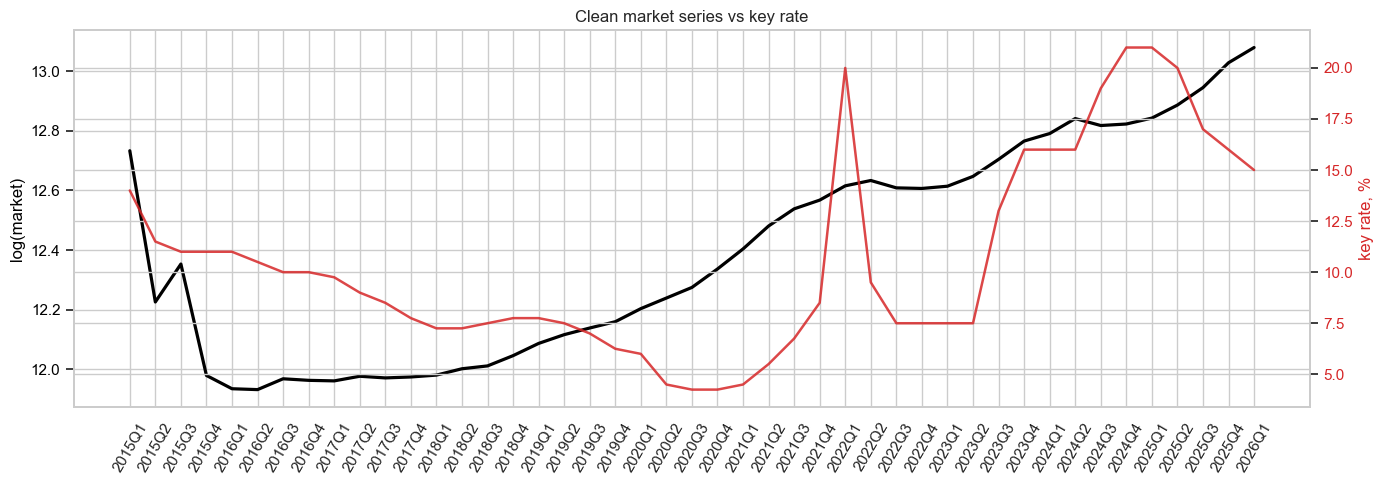

In [2]:
display(panel[['quarter_norm', target_col, 'actual_log_price_median', 'key_rate_avg_q', 'key_rate_eoq', 'key_rate_qoq_change']].head(8))
display(panel[['quarter_norm', target_col, 'actual_log_price_median', 'key_rate_avg_q', 'key_rate_eoq', 'key_rate_qoq_change']].tail(8))

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(panel['quarter_norm'], panel[target_col], color='black', lw=2.3, label='market_log_level_q')
ax1.set_ylabel('log(market)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.tick_params(axis='x', rotation=60)
ax2 = ax1.twinx()
ax2.plot(panel['quarter_norm'], panel['key_rate_eoq'], color='#d62728', lw=1.8, alpha=0.85, label='key_rate_eoq')
ax2.set_ylabel('key rate, %', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')
ax1.set_title('Clean market series vs key rate')
fig.tight_layout()
plt.show()


## 2. Feature Families

We compare a few trend constructions on the target itself and then add the key-rate block on top:

- `lin_*`: linear extrapolation of recent market levels
- `sma_*`: simple moving average trend
- `ema_*`: exponentially weighted moving average trend
- `poly_*`: local polynomial trend

The test block is held out as a contiguous window. For that block, trend features are extrapolated from pre-test history only.

We also evaluate the trend constructions directly, before adding any regression model, so the notebook can answer two questions separately:
1. which raw trend construction is best on its own;
2. which combination of trend features + key rate is best after a regression layer.

In [3]:
feature_sets = {
    'key_rate_only': key_rate_columns,
    'lin_plus_key': [c for c in trend_columns if c.startswith('lin_')] + key_rate_columns,
    'sma_plus_key': [c for c in trend_columns if c.startswith('sma_')] + key_rate_columns,
    'ema_plus_key': [c for c in trend_columns if c.startswith('ema_')] + key_rate_columns,
    'poly_plus_key': [c for c in trend_columns if c.startswith('poly_')] + key_rate_columns,
    'combo_trend_only': trend_columns,
    'combo_trend_plus_key': trend_columns + key_rate_columns,
}

model_kinds = ['linear', 'ridge', 'lasso', 'elasticnet', 'huber']
positions = generate_test_positions(len(panel), test_frac=0.30, n_positions=10)

print('Feature sets:')
for name, cols in feature_sets.items():
    print(f'  {name:20s} {len(cols):2d} features')
print('\nTest positions:')
for i, (ts, te) in enumerate(positions):
    print(f'  {i:02d}: {panel.quarter_norm.iloc[ts]} -> {panel.quarter_norm.iloc[te-1]}  ({te-ts} quarters)')


Feature sets:
  key_rate_only        11 features
  lin_plus_key         14 features
  sma_plus_key         14 features
  ema_plus_key         14 features
  poly_plus_key        14 features
  combo_trend_only     12 features
  combo_trend_plus_key 23 features

Test positions:
  00: 2015Q1 -> 2018Q2  (14 quarters)
  01: 2015Q4 -> 2019Q1  (14 quarters)
  02: 2016Q4 -> 2020Q1  (14 quarters)
  03: 2017Q3 -> 2020Q4  (14 quarters)
  04: 2018Q3 -> 2021Q4  (14 quarters)
  05: 2019Q2 -> 2022Q3  (14 quarters)
  06: 2020Q2 -> 2023Q3  (14 quarters)
  07: 2021Q1 -> 2024Q2  (14 quarters)
  08: 2022Q1 -> 2025Q2  (14 quarters)
  09: 2022Q4 -> 2026Q1  (14 quarters)


## 3. Block Evaluation

For each test window we fit on all other quarters. The test window itself never enters the feature construction.

This is the main thing that matters here:
- the model can use history after the test window for training rows outside the hold-out block;
- the hold-out block uses only pre-test history plus known key-rate values for the corresponding quarter.


In [4]:
results = []
coef_rows = []
pred_rows = []
trend_baseline_rows = []

for pos_idx, (test_start, test_end) in enumerate(positions):
    trend_frame = build_trend_feature_frame(y, test_start=test_start, test_end=test_end, windows=DEFAULT_TREND_WINDOWS)
    feature_frame = pd.concat([trend_frame, key_rate_frame], axis=1)
    train_mask = np.ones(len(panel), dtype=bool)
    train_mask[test_start:test_end] = False
    test_mask = ~train_mask
    y_train = y[train_mask]
    y_test = y[test_mask]

    # simple naive baseline: carry the last observed pre-test level through the block
    naive_pred = np.full(test_end - test_start, y[test_start - 1] if test_start > 0 else y[0], dtype=float)
    results.append(regression_metrics(y_test, naive_pred, name='naive_last_value', scope=f'pos_{pos_idx:02d}').assign(
        pos_idx=pos_idx, test_start=test_start, test_end=test_end, feature_set='baseline', model_kind='naive'
    ))
    for trend_col in trend_columns:
        trend_pred = trend_frame[trend_col].iloc[test_start:test_end].to_numpy(dtype=float)
        trend_baseline_rows.append(
            regression_metrics(y_test, trend_pred, name=trend_col, scope=f'pos_{pos_idx:02d}')
            .assign(pos_idx=pos_idx, test_start=test_start, test_end=test_end, feature_set='trend_direct', model_kind=trend_col)
        )

    for feature_set_name, feature_cols in feature_sets.items():
        X = feature_frame[feature_cols]
        X_train = X.loc[train_mask]
        X_test = X.loc[test_mask]

        for model_kind in model_kinds:
            pipe = build_model_pipeline(model_kind)
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)
            metrics = regression_metrics(y_test, y_pred, name=f'{feature_set_name}__{model_kind}', scope=f'pos_{pos_idx:02d}')
            metrics = metrics.assign(pos_idx=pos_idx, test_start=test_start, test_end=test_end, feature_set=feature_set_name, model_kind=model_kind)
            results.append(metrics)

            coef_rows.append(
                extract_coefficients(pipe, feature_cols, model_name=f'{feature_set_name}__{model_kind}', scope=f'pos_{pos_idx:02d}')
                .assign(pos_idx=pos_idx, test_start=test_start, test_end=test_end, feature_set=feature_set_name, model_kind=model_kind)
            )

            pred_rows.append(
                pd.DataFrame({
                    'pos_idx': pos_idx,
                    'test_start': test_start,
                    'test_end': test_end,
                    'feature_set': feature_set_name,
                    'model_kind': model_kind,
                    'quarter_norm': panel.loc[test_mask, 'quarter_norm'].to_numpy(),
                    'y_true': y_test,
                    'y_pred': y_pred,
                })
            )

results_df = pd.concat(results, ignore_index=True)
trend_baseline_df = pd.concat(trend_baseline_rows, ignore_index=True)
pred_df = pd.concat(pred_rows, ignore_index=True)
coef_df = pd.concat([c for c in coef_rows if len(c) > 0], ignore_index=True) if coef_rows else pd.DataFrame()

results_df.to_csv(DATA_DIR / 'metrics_by_position.csv', index=False)
trend_baseline_df.to_csv(DATA_DIR / 'trend_baselines_by_position.csv', index=False)
pred_df.to_csv(DATA_DIR / 'predictions_by_position.csv', index=False)
if len(coef_df) > 0:
    coef_df.to_csv(DATA_DIR / 'coefficients_by_position.csv', index=False)

print('Saved:')
for p in sorted(DATA_DIR.glob('*.csv')):
    print(f'  {p.name:32s} {p.stat().st_size} B')


C:\Users\egort\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


C:\Users\egort\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Saved:
  coefficients_by_position.csv     472227 B
  metrics_by_position.csv          42993 B
  predictions_by_position.csv      369927 B
  trend_baselines_by_position.csv  12112 B


## 4. Summary

We care most about average performance across test windows, not about a single lucky split. Because these test blocks are short, `R2` is noisy, so the primary ranking is by `RMSE_log`, then `MAE_log`.

R2  MAE_log  RMSE_log
feature_set          model_kind                               
ema_plus_key         ridge         -20.7665   0.2487    0.2913
                     elasticnet    -19.2360   0.2476    0.2920
                     lasso         -21.9081   0.2602    0.3068
baseline             naive         -11.8063   0.2767    0.3111
ema_plus_key         linear        -15.6915   0.2772    0.3377
sma_plus_key         ridge         -26.1740   0.3002    0.3468
                     lasso         -27.5011   0.2970    0.3495
key_rate_only        linear        -18.1448   0.2707    0.3518
sma_plus_key         elasticnet    -27.7109   0.3024    0.3548
key_rate_only        ridge         -22.1189   0.3082    0.3648
ema_plus_key         huber         -56.5547   0.3105    0.3649
sma_plus_key         linear        -24.5428   0.3184    0.3702
key_rate_only        huber         -18.1785   0.3014    0.3782
                     lasso         -20.0007   0.3281    0.3799
                     elasticnet    -22.7229   0.3407    0.3964
combo_trend_plus_key elasticnet    -30.5862   0.3558    0.4143
lin_plus_key         ridge        -140.4783   0.3452    0.4161
                     linear       -108.6450   0.3251    0.4217
combo_trend_plus_key lasso         -34.1508   0.3715    0.4274
lin_plus_key         lasso        -350.0749   0.3812    0.4605
                     elasticnet   -348.4879   0.3813    0.4607
sma_plus_key         huber         -48.5640   0.4151    0.4770
combo_trend_only     huber        -107.9106   0.3874    0.4784
                     lasso        -196.6766   0.4346    0.5080
poly_plus_key        linear       -104.1818   0.4636    0.5821
combo_trend_only     ridge        -117.1214   0.5190    0.5863
lin_plus_key         huber        -913.0020   0.5145    0.5996
poly_plus_key        lasso        -344.8159   0.4977    0.6034
                     ridge        -153.5988   0.5114    0.6152
combo_trend_only     elasticnet   -253.0555   0.5592    0.6448
combo_trend_plus_key ridge        -225.1691   0.5624    0.6459
poly_plus_key        elasticnet   -344.9632   0.5381    0.6464
                     huber        -862.8824   0.6037    0.7064
combo_trend_plus_key huber        -212.7027   0.6905    0.8196
combo_trend_only     linear      -6156.0843   3.2046    5.8472
combo_trend_plus_key linear     -34932.0626   7.1425   13.5397

,R2,MAE_log,RMSE_log
model_kind,,,
sma_3,-50.2237,0.2866,0.3405
ema_3,-87.7032,0.3136,0.3751
sma_6,-45.9496,0.3483,0.4093
ema_6,-88.2552,0.3611,0.4290
sma_10,-48.1765,0.4394,0.5020
ema_10,-92.8527,0.4390,0.5084
lin_3,-1240.2783,0.5775,0.6640
poly_6,-1261.7094,0.6732,0.7774
lin_6,-1291.5498,0.7011,0.7919


,R2,MAE_log,RMSE_log
feature_set,,,
baseline,-11.8063,0.2767,0.3111
ema_plus_key,-26.8314,0.2688,0.3185
key_rate_only,-20.2332,0.3098,0.3742
sma_plus_key,-30.8986,0.3266,0.3797
lin_plus_key,-372.1376,0.3895,0.4717
poly_plus_key,-362.0884,0.5229,0.6307
combo_trend_only,-1366.1697,1.0209,1.6130
combo_trend_plus_key,-7086.9343,1.8245,3.1694


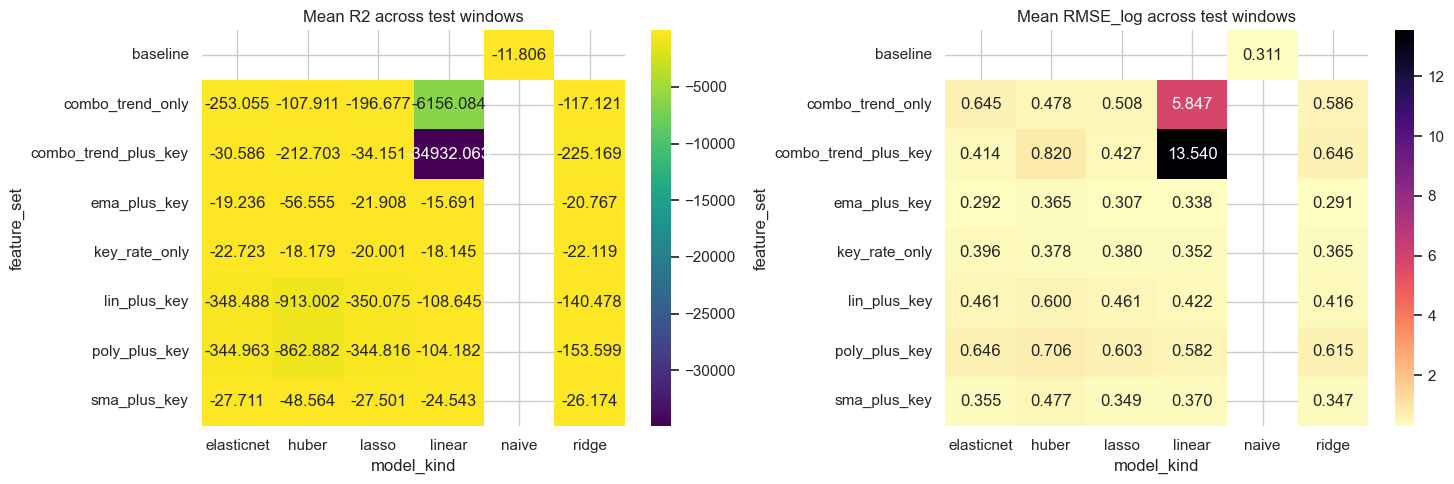

In [5]:
summary = (
    results_df.groupby(['feature_set', 'model_kind'])[['R2', 'MAE_log', 'RMSE_log']]
    .mean()
    .sort_values(['RMSE_log', 'MAE_log'], ascending=[True, True])
    .round(4)
)
display(summary)

trend_summary = (
    trend_baseline_df.groupby('model_kind')[['R2', 'MAE_log', 'RMSE_log']]
    .mean()
    .sort_values(['RMSE_log', 'MAE_log'], ascending=[True, True])
    .round(4)
)
display(trend_summary)

family_summary = (
    results_df.groupby('feature_set')[['R2', 'MAE_log', 'RMSE_log']]
    .mean()
    .sort_values(['RMSE_log', 'MAE_log'], ascending=[True, True])
    .round(4)
)
display(family_summary)

pivot_r2 = results_df.pivot_table(index='feature_set', columns='model_kind', values='R2', aggfunc='mean').round(3)
pivot_rmse = results_df.pivot_table(index='feature_set', columns='model_kind', values='RMSE_log', aggfunc='mean').round(3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='viridis', ax=axes[0])
axes[0].set_title('Mean R2 across test windows')
sns.heatmap(pivot_rmse, annot=True, fmt='.3f', cmap='magma_r', ax=axes[1])
axes[1].set_title('Mean RMSE_log across test windows')
fig.tight_layout()
plt.show()


## 5. Best Model Inspection

We pick the best average `RMSE_log` model and look at one representative hold-out window.

Best average model by RMSE: ema_plus_key + ridge


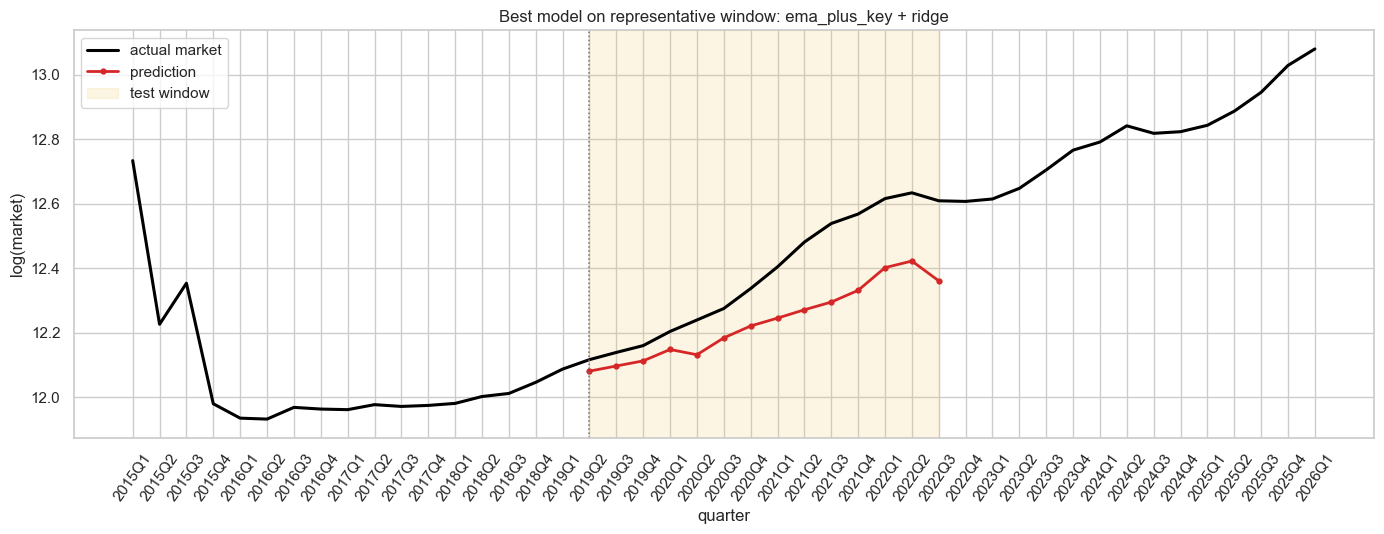

In [6]:
best_row = summary.reset_index().sort_values(['RMSE_log', 'MAE_log'], ascending=[True, True]).iloc[0]
best_feature_set = best_row['feature_set']
best_model_kind = best_row['model_kind']
print(f'Best average model by RMSE: {best_feature_set} + {best_model_kind}')

rep_pos = len(positions) // 2
rep_ts, rep_te = positions[rep_pos]
rep_pred = pred_df[(pred_df.pos_idx == rep_pos) & (pred_df.feature_set == best_feature_set) & (pred_df.model_kind == best_model_kind)].copy()
rep_pred = rep_pred.sort_values('quarter_norm')

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(panel['quarter_norm'], panel[target_col], color='black', lw=2.2, label='actual market')
ax.plot(rep_pred['quarter_norm'], rep_pred['y_pred'], color='#d62728', lw=2.0, marker='o', ms=3.5, label='prediction')
ax.axvspan(panel.loc[rep_ts, 'quarter_norm'], panel.loc[rep_te - 1, 'quarter_norm'], color='#f3c969', alpha=0.18, label='test window')
ax.axvline(panel.loc[rep_ts, 'quarter_norm'], color='0.45', ls=':', lw=1.1)
ax.set_title(f'Best model on representative window: {best_feature_set} + {best_model_kind}')
ax.set_ylabel('log(market)')
ax.set_xlabel('quarter')
ax.tick_params(axis='x', rotation=55)
ax.legend(loc='best', frameon=True)
fig.tight_layout()
plt.show()


## 6. Coefficients

For interpretable models, we can aggregate coefficients across windows and inspect what the model uses most.

In [7]:
if len(coef_df) > 0:
    if 'coef' in coef_df.columns:
        coef_summary = (
            coef_df.groupby(['feature_set', 'model_kind', 'feature'])['coef']
            .agg(['mean', 'median', 'std'])
            .reset_index()
            .sort_values(['feature_set', 'model_kind', 'mean'], ascending=[True, True, False])
        )
        display(coef_summary.head(30))
        key_coef = coef_summary[coef_summary['feature'].isin(key_rate_columns)].copy()
        display(key_coef.sort_values(['feature_set', 'model_kind', 'mean'], ascending=[True, True, False]).head(30))
else:
    print('No coefficient table was produced.')


,feature_set,model_kind,feature,mean,median,std
4,combo_trend_only,elasticnet,lin_3,0.233544,0.180446,0.161976
10,combo_trend_only,elasticnet,sma_3,0.185184,0.141651,0.125516
1,combo_trend_only,elasticnet,ema_3,0.103116,0.093551,0.077199
7,combo_trend_only,elasticnet,poly_3,0.070707,0.061416,0.039574
2,combo_trend_only,elasticnet,ema_6,0.044377,0.007849,0.064394
11,combo_trend_only,elasticnet,sma_6,0.023584,0.000000,0.077852
5,combo_trend_only,elasticnet,lin_6,0.015966,0.000000,0.043957
8,combo_trend_only,elasticnet,poly_6,-0.020256,-0.007758,0.059871
9,combo_trend_only,elasticnet,sma_10,-0.027602,0.000000,0.087389
3,combo_trend_only,elasticnet,lin_10,-0.090117,0.000000,0.139806


,feature_set,model_kind,feature,mean,median,std
69,combo_trend_plus_key,elasticnet,key_rate_ma_8,0.246785,0.262310,0.182735
68,combo_trend_plus_key,elasticnet,key_rate_ma_4,0.159684,0.179043,0.109478
71,combo_trend_plus_key,elasticnet,key_rate_min_q,0.053999,0.051510,0.035903
67,combo_trend_plus_key,elasticnet,key_rate_log_return_q,0.020017,0.007052,0.023230
70,combo_trend_plus_key,elasticnet,key_rate_max_q,0.014450,0.007627,0.016397
66,combo_trend_plus_key,elasticnet,key_rate_eoq,0.011625,0.005914,0.016622
63,combo_trend_plus_key,elasticnet,key_rate_avg_q,0.007634,0.000000,0.020107
73,combo_trend_plus_key,elasticnet,key_rate_spread_q,-0.003929,-0.000000,0.009395
72,combo_trend_plus_key,elasticnet,key_rate_qoq_change,-0.011822,0.000000,0.021564
64,combo_trend_plus_key,elasticnet,key_rate_ema_4,-0.020167,-0.000000,0.038805


## 7. Takeaway

The practical recipe is the one that wins on average across many blocked windows, not the one that looks best on a single split.

For this market series, the rule of thumb is:
1. train on multiple disjoint periods and average across blocked test windows;
2. keep the macro block narrow: key rate only;
3. compare several trend constructions directly, then compare them again after a regression layer;
4. rank models primarily by mean out-of-block `RMSE_log` and use `R2` only as a secondary sanity check;
5. on this series, EMA-based trend features are the strongest starting point among the tested families.
